--- Prime 5 righe del dataset ---


,Age,Gender,Job,Area,CitySize,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,Luxury,Saving,Investments
0,24,1,1,2,2,4,0.668046,0.702786,0.262070,0.741853,0.483684,0.698625,0.618259,0.607877,0.897369,0.283222,1
1,47,1,2,2,3,1,0.858453,0.915043,0.730430,0.859423,0.537167,0.959025,0.785936,0.862271,0.913729,0.821590,3
2,38,0,2,1,2,2,0.926818,0.898316,0.441272,0.485953,0.649434,0.750265,0.699725,0.755404,0.765199,0.503790,3
3,67,0,2,1,2,3,0.538797,0.423180,0.600401,0.493144,0.533829,0.590165,0.675353,0.334432,0.517209,0.691240,2
4,33,0,2,1,3,1,0.806659,0.731404,0.831449,0.856286,0.784940,0.710026,0.758793,0.908878,0.611610,0.615916,2



--- Statistiche Descrittive (Media, Min, Max) ---


,Age,Gender,Job,Area,CitySize,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,Luxury,Saving,Investments
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,60.45,0.53,2.46,1.38,1.93,2.49,0.58,0.58,0.43,0.51,0.59,0.53,0.62,0.46,0.47,0.52,2.18
std,21.82,0.50,1.25,0.68,0.76,1.41,0.21,0.21,0.22,0.19,0.17,0.21,0.16,0.22,0.24,0.19,0.82
min,19.00,0.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.04,0.00,0.12,0.00,0.00,0.00,1.00
25%,42.00,0.00,2.00,1.00,1.00,1.00,0.41,0.42,0.26,0.37,0.47,0.37,0.51,0.28,0.27,0.40,1.00
50%,61.00,1.00,2.00,1.00,2.00,2.00,0.58,0.59,0.45,0.50,0.60,0.52,0.63,0.45,0.46,0.54,2.00
75%,80.00,1.00,2.00,2.00,3.00,3.00,0.75,0.75,0.60,0.65,0.71,0.70,0.75,0.64,0.66,0.66,3.00
max,95.00,1.00,5.00,3.00,3.00,6.00,0.98,1.00,0.98,0.96,0.99,0.97,0.97,0.99,1.00,0.97,3.00


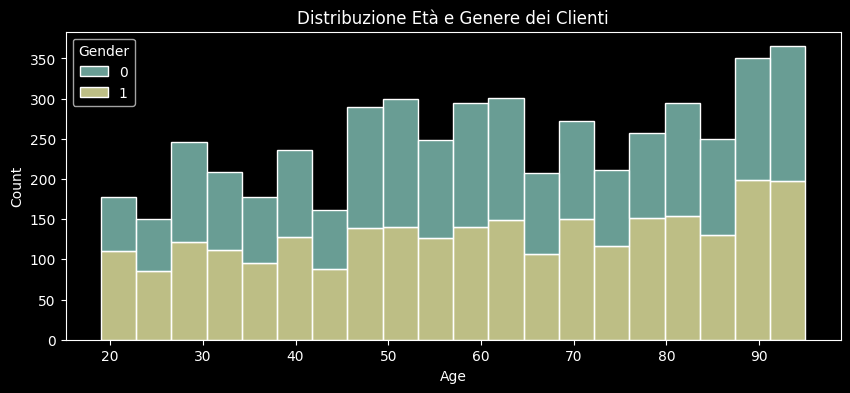

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Usiamo read_excel invece di read_csv e scriviamo l'estensione corretta!
df = pd.read_excel('Dataset1_BankClients.xlsx')

# Rimuoviamo l'ID perché non serve per fare i gruppi
df = df.drop(columns=['ID'])

# 2. Mostriamo le prime 5 righe e le statistiche base
print("--- Prime 5 righe del dataset ---")
display(df.head())

print("\n--- Statistiche Descrittive (Media, Min, Max) ---")
display(df.describe().round(2))

# 3. Facciamo un primo grafico per l'età e il genere
plt.figure(figsize=(10, 4))
sns.histplot(data=df, x='Age', hue='Gender', multiple='stack', bins=20)
plt.title('Distribuzione Età e Genere dei Clienti')
plt.show()

Now we convert categorical variables

In [19]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
import numpy as np

# For not ordered features we use One-Hot encoding
no_order_columns = ['Job', 'Area', 'Investments']
no_order_features = df[no_order_columns]
no_order_features = no_order_features.astype('category')

encoder = OneHotEncoder(drop='first', handle_unknown='ignore')  # Dummy encoding - ignoring unknwown values
X_no_order = encoder.fit_transform(no_order_features).toarray()  # Convert into a dense matrix

# normalize ordered categorical features
order_columns = ['Age', 'CitySize', 'FamilySize']
order_features = df[order_columns]

scaler = MinMaxScaler()
X_order = scaler.fit_transform(order_features)

numerical_features = df.drop(columns=no_order_columns + order_columns)
X_num = scaler.fit_transform(numerical_features)

X=np.hstack((X_num, X_order, X_no_order))
print(X)

[[1.         0.67959899 0.70589454 ... 0.         0.         0.        ]
 [1.         0.8732994  0.91909035 ... 0.         0.         1.        ]
 [0.         0.94284635 0.90228868 ... 0.         0.         1.        ]
 ...
 [1.         0.71043506 0.83707191 ... 0.         0.         1.        ]
 [0.         0.91381046 0.83132005 ... 0.         0.         1.        ]
 [1.         0.81016577 0.71209775 ... 0.         0.         1.        ]]


We come back to pandas

In [20]:
# 1. Recuperiamo i nomi delle colonne per ogni gruppo (esattamente come li avevamo divisi)
# Nomi delle variabili numeriche
numeric_column_names = numerical_features.columns.tolist()

# Nomi delle variabili ordinali
order_column_names = order_columns

# Nomi delle nuove variabili create dal One-Hot Encoder (es. Job_2, Area_3, ecc.)
encoded_column_names = encoder.get_feature_names_out(no_order_columns)

# 2. Uniamo le liste dei nomi nello STESSO IDENTICO ORDINE in cui abbiamo unito le matrici
# Nel tuo hstack avevi messo: 1° X_num, 2° X_order, 3° X_no_order
all_column_names = numeric_column_names + order_column_names + list(encoded_column_names)

# 3. Creiamo il DataFrame Pandas finale
df_scaled = pd.DataFrame(X, columns=all_column_names)

# Mostriamo le prime righe per verificare che sia tutto corretto
print("--- DataFrame pronto per il Clustering ---")
display(df_scaled.head())

--- DataFrame pronto per il Clustering ---


,Gender,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,Luxury,...,CitySize,FamilySize,Job_2,Job_3,Job_4,Job_5,Area_2,Area_3,Investments_2,Investments_3
0,1.0,0.679599,0.705895,0.268264,0.770735,0.465122,0.718914,0.581720,0.612604,0.901051,...,0.5,0.6,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,1.0,0.873299,0.919090,0.747693,0.892883,0.521675,0.986877,0.778748,0.868977,0.917477,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,0.0,0.942846,0.902289,0.451701,0.504873,0.640388,0.772055,0.677446,0.761279,0.768338,...,0.5,0.2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.548115,0.425051,0.614591,0.512343,0.518146,0.607305,0.648808,0.337033,0.519331,...,0.5,0.4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.820609,0.734639,0.851100,0.889625,0.783674,0.730646,0.746853,0.915946,0.614119,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
